<a href="https://colab.research.google.com/github/khalilullahalfaath/comparing-ranked-retrieval-models/blob/main/1_STBI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('https://github.com/khalilullahalfaath/comparing-ranked-retrieval-models/blob/main/data/News.csv?raw=True')

In [36]:
df.head()

,id,id_author,title,portal,time,author,editor,content,source
0,0,1,Infografis Pekerja Asing Dilarang Masuk Wilaya...,Liputan6.com,"24 Jul 2021, 09:02 WIB",Abdillah,Abdillah,Pemerintah melalui Menteri Hukum dan Hak Asasi...,https://www.liputan6.com/news/read/4614451/inf...
1,1,1,Infografis Jadwal Bulu Tangkis Indonesia di Ol...,Liputan6.com,"23 Jul 2021, 23:23 WIB",Abdillah,Abdillah,Bulu Tangkis menjadi andalan Indonesia berburu...,https://www.liputan6.com/bola/read/4614427/inf...
2,2,1,"Infografis Jangan Bebal, Kamu Tidak Kebal Covi...",Liputan6.com,"23 Jul 2021, 10:40 WIB",Abdillah,Abdillah,Covid-19 tidak mengenal usia dan status. Siapa...,https://www.liputan6.com/news/read/4613233/inf...
3,3,1,Infografis Awas Perokok Lebih Rentan Tertular ...,Liputan6.com,"22 Jul 2021, 10:35 WIB",Abdillah,Abdillah,Kebiasaan merokok berisiko menimbulkan sejumla...,https://www.liputan6.com/news/read/4612324/inf...
4,4,1,Infografis Perbedaan Aturan PPKM Level 3 dan 4,Liputan6.com,"22 Jul 2021, 09:01 WIB",Abdillah,Abdillah,Pemberlakuan Pembatasan Kegiatan Masyarakat at...,https://www.liputan6.com/news/read/4612511/inf...


In [37]:
# Use only the content column
df_content_only = pd.DataFrame(df['content'])
df_content_only.head()

,content
0,Pemerintah melalui Menteri Hukum dan Hak Asasi...
1,Bulu Tangkis menjadi andalan Indonesia berburu...
2,Covid-19 tidak mengenal usia dan status. Siapa...
3,Kebiasaan merokok berisiko menimbulkan sejumla...
4,Pemberlakuan Pembatasan Kegiatan Masyarakat at...


# Exploring dataset
In this section, I've explored statistical characteristics of the dataset.

In [38]:
df_content_only.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14343 entries, 0 to 14342
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  14334 non-null  object
dtypes: object(1)
memory usage: 112.2+ KB


We can see that there are 14,343 docs in this dataset.

In [39]:
# delete NaN rows
df_content_only = df_content_only.dropna(subset=['content'])

df_content_only = df_content_only[df_content_only['content'].str.strip() != ""]

df_content_only = df_content_only.reset_index(drop=True)

In [40]:
df_content_only.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14334 entries, 0 to 14333
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  14334 non-null  object
dtypes: object(1)
memory usage: 112.1+ KB


In [41]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Hitung jumlah dokumen
num_docs = len(df_content_only)

# Hitung kata dan kalimat
df_content_only['word_count'] = df_content_only['content'].apply(lambda x: len(str(x).split()))
df_content_only['sentence_count'] = df_content_only['content'].apply(lambda x: len(nltk.sent_tokenize(str(x))))

print(f"Total Dokumen: {num_docs}")
print(f"Total Kata: {df_content_only['word_count'].sum()}")
print(f"Rata-rata Kata per Dokumen: {df_content_only['word_count'].mean():.2f}")
print(f"Total Kalimat: {df_content_only['sentence_count'].sum()}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total Dokumen: 14334
Total Kata: 5524047
Rata-rata Kata per Dokumen: 385.38
Total Kalimat: 352472


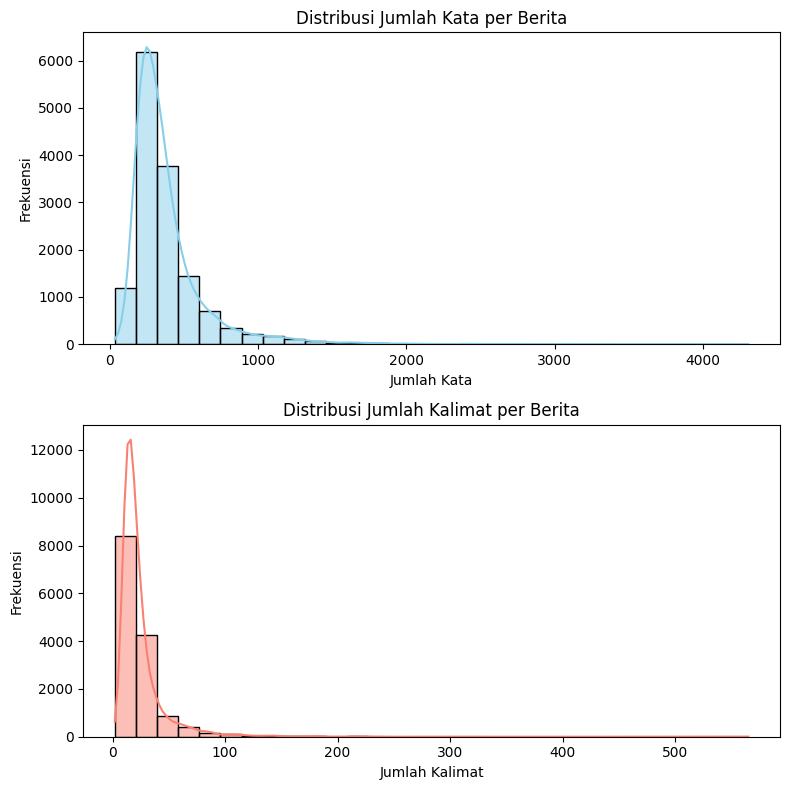

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

sns.histplot(df_content_only['word_count'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Jumlah Kata per Berita')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df_content_only['sentence_count'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribusi Jumlah Kalimat per Berita')
axes[1].set_xlabel('Jumlah Kalimat')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Modeling
Since we were not needed to do data preprocessing, we straightforward create the retrieval models.

In [43]:
import time

## TF-IDF

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

start_time = time.time()
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_content_only['content'].fillna(""))
tfidf_index_time = time.time() - start_time
print(f"TF-IDF Vectorization Time: {tfidf_index_time:.2f} seconds")

TF-IDF Vectorization Time: 4.29 seconds


In [45]:
tfidf_matrix.shape

(14334, 90903)

## Word2vec

In [46]:
!pip install gensim

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
from gensim.models import Word2Vec

model_path = "/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/STBI/wiki.id.case.model"

start_time = time.time()
wv3 = Word2Vec.load(model_path)
print(f"Vector size: {wv3.vector_size}")

Vector size: 400


In [49]:
def get_doc_vector(text, model):
    # split text based on space
    words = str(text).split()

    vectors = []
    for w in words:
        if w in model.wv:
            vectors.append(model.wv[w])
        elif w.lower() in model.wv:
            vectors.append(model.wv[w.lower()])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    # mean pooling
    return np.mean(vectors, axis=0)


In [50]:
start_w2v_indexing = time.time()

w2v_matrix = np.array([get_doc_vector(doc, wv3) for doc in df_content_only['content']])

w2v_index_time = time.time() - start_w2v_indexing
print(f"Indexing: {w2v_index_time:.4f} detik!")
print(f"Ukuran w2v_matrix: {w2v_matrix.shape}")

Indexing: 13.4232 detik!
Ukuran w2v_matrix: (14334, 400)


## Indo-BERT

In [51]:
!pip install sentence-transformers

In [52]:
from sentence_transformers import SentenceTransformer
import time
import numpy as np

# start_time = time.time()

bert_model = SentenceTransformer('indobenchmark/indobert-base-p1')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [53]:
start_bert_indexing = time.time()

dokumen_list = df_content_only['content'].fillna("").astype(str).tolist()

bert_matrix = bert_model.encode(dokumen_list, show_progress_bar=True)

bert_index_time = time.time() - start_bert_indexing
print(f"Indexing IndoBERT selesai dalam {bert_index_time:.4f} detik!")
print(f"Ukuran bert_matrix: {bert_matrix.shape}")

Batches:   0%|          | 0/448 [00:00<?, ?it/s]

Indexing IndoBERT selesai dalam 385.2356 detik!
Ukuran bert_matrix: (14334, 768)


# Evaluation

In [54]:
def search_documents(query, matrix, model_type, top_k=3):
    start_time = time.time()

    # query conversion
    if model_type == 'TF-IDF':
        query_vec = tfidf_vectorizer.transform([query])
    elif model_type == 'Word2Vec':
        query_vec = get_doc_vector(query, wv3).reshape(1, -1)
    elif model_type == 'IndoBERT':
        query_vec = bert_model.encode([query])

    # compute cosine similarity
    similarities = cosine_similarity(query_vec, matrix).flatten()

    # top 3
    top_indices = similarities.argsort()[-top_k:][::-1]
    top_scores = similarities[top_indices]

    query_time = time.time() - start_time
    return top_indices, top_scores, query_time

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

# queries = [
#     # skenario yang persis ada di berita
#     "Laju Indeks Harga Saham Gabungan (IHSG) menguat",
#     "pergerakan indeks harga saham gabungan ihsg",
#     "kasus tindak pidana korupsi pejabat daerah",
#     "perkembangan kecerdasan buatan dan teknologi",
#     "penanganan kasus pasien di rumah sakit",
#     "kenaikan harga bahan bakar minyak bbm",
#     "dampak bencana alam gempa bumi dan banjir",
#     "kebijakan sistem pendidikan dan sekolah",
#     "rilis film bioskop terbaru tahun ini",
#     "cuaca ekstrem yang menyebabkan gagal panen petani"
# ]

queries = [
    # Skenario Exact Entity & Akronim
    "pergerakan indeks harga saham gabungan ihsg di bursa efek",

    # Skenario Sinonim Murni
    "bantuan dana tunai untuk warga kurang mampu",

    # Skenario Polisemi / Makna Ganda (bunga bank dan tanaman)
    "penurunan suku bunga bank indonesia untuk kredit",

    # Skenario Konsep Implisit
    "wabah penyakit pernapasan mematikan terjadi di seluruh dunia",

    # Skenario OOV (Out-of-Vocabulary) Trap
    "investasi aset kripto bitcoin dan ethereum",

    # Skenario Relasi Aksi & Entitas (Menguji penggabungan aksi OTT dengan subjek KPK/Pejabat)
    "operasi tangkap tangan pejabat daerah oleh komisi pemberantasan korupsi",

    # Skenario Sentimen / Penolakan (Menguji kelemahan Word2Vec dalam merata-ratakan sentimen oposisi/protes)
    "penolakan warga terhadap aturan pembatasan mobilitas",

    # Skenario Topik Hiburan & Konteks Lemah (Menguji pemisahan kata kiasan "drama" di politik vs film bioskop)
    "ulasan dan rating film bioskop bergenre drama percintaan",

    # Skenario Spesifik Event (Menguji penghubungan kata umum ke entitas tren spesifik seperti Euro 2020)
    "hasil pertandingan final kejuaraan sepak bola eropa",

    # Skenario Kausalitas / Sebab-Akibat (Menguji pemahaman sebab bencana dan akibat ke pertanian)
    "cuaca ekstrem yang mengakibatkan gagal panen padi petani"
]

data_hasil = []
time_records = []

for query in queries:
    idx_tfidf, score_tfidf, time_tfidf = search_documents(query, tfidf_matrix, 'TF-IDF', top_k=3)
    idx_w2v, score_w2v, time_w2v = search_documents(query, w2v_matrix, 'Word2Vec', top_k=3)
    idx_bert, score_bert, time_bert = search_documents(query, bert_matrix, 'IndoBERT', top_k=3)

    time_records.extend([
        {'Model': 'TF-IDF', 'Query': query, 'Time (s)': time_tfidf},
        {'Model': 'Word2Vec', 'Query': query, 'Time (s)': time_w2v},
        {'Model': 'IndoBERT', 'Query': query, 'Time (s)': time_bert}
    ])

    for i in range(3):
        data_hasil.append({'Kueri': query, 'Model': 'TF-IDF', 'Rank': i+1, 'Skor': score_tfidf[i], 'Teks': str(df_content_only['content'].iloc[idx_tfidf[i]])[:500]})
        data_hasil.append({'Kueri': query, 'Model': 'Word2Vec', 'Rank': i+1, 'Skor': score_w2v[i], 'Teks': str(df_content_only['content'].iloc[idx_w2v[i]])[:500]})
        data_hasil.append({'Kueri': query, 'Model': 'IndoBERT', 'Rank': i+1, 'Skor': score_bert[i], 'Teks': str(df_content_only['content'].iloc[idx_bert[i]])[:500]})

df_hasil = pd.DataFrame(data_hasil)

# Simpan ke Excel dan TXT
df_hasil.to_excel('Hasil_Top3_Retrieval.xlsx', index=False)
df_hasil.to_csv('Hasil_Top3_Retrieval.txt', sep='\t', index=False)

df_time = pd.DataFrame(time_records)
print(df_time.groupby('Model')['Time (s)'].mean())

Model
IndoBERT    0.086473
TF-IDF      0.093741
Word2Vec    0.029760
Name: Time (s), dtype: float64


In [60]:
df_hasil

,Kueri,Model,Rank,Skor,Teks
0,pergerakan indeks harga saham gabungan ihsg di...,TF-IDF,1,0.563773,Indeks Harga Saham Gabungan (IHSG) di Bursa ...
1,pergerakan indeks harga saham gabungan ihsg di...,Word2Vec,1,0.839335,Indeks Harga Saham Gabungan (IHSG) di Bursa ...
2,pergerakan indeks harga saham gabungan ihsg di...,IndoBERT,1,0.455867,Bursa saham Asia Pasifik turun pada perdaganga...
3,pergerakan indeks harga saham gabungan ihsg di...,TF-IDF,2,0.557220,Indeks Harga Saham Gabungan (IHSG) di Bursa ...
4,pergerakan indeks harga saham gabungan ihsg di...,Word2Vec,2,0.838964,Indeks Harga Saham gabungan (IHSG) Bursa Efe...
...,...,...,...,...,...
85,cuaca ekstrem yang mengakibatkan gagal panen p...,Word2Vec,2,0.807577,"Panen raya di Jatiluwih, Kabupaten Tabanan, ..."
86,cuaca ekstrem yang mengakibatkan gagal panen p...,IndoBERT,2,0.482287,Permukiman warga di 5 Kampung di Distrik Waa...
87,cuaca ekstrem yang mengakibatkan gagal panen p...,TF-IDF,3,0.308236,"Panen raya di Jatiluwih, Kabupaten Tabanan, ..."
88,cuaca ekstrem yang mengakibatkan gagal panen p...,Word2Vec,3,0.806240,Lahan pertanian seluas 300 hektar di Kecamat...


In [61]:
df_time

,Model,Query,Time (s)
0,TF-IDF,pergerakan indeks harga saham gabungan ihsg di...,0.093551
1,Word2Vec,pergerakan indeks harga saham gabungan ihsg di...,0.029209
2,IndoBERT,pergerakan indeks harga saham gabungan ihsg di...,0.155287
3,TF-IDF,bantuan dana tunai untuk warga kurang mampu,0.113557
4,Word2Vec,bantuan dana tunai untuk warga kurang mampu,0.037626
5,IndoBERT,bantuan dana tunai untuk warga kurang mampu,0.133039
6,TF-IDF,penurunan suku bunga bank indonesia untuk kredit,0.145285
7,Word2Vec,penurunan suku bunga bank indonesia untuk kredit,0.030151
8,IndoBERT,penurunan suku bunga bank indonesia untuk kredit,0.076033
9,TF-IDF,wabah penyakit pernapasan mematikan terjadi di...,0.149103
